# Week-1 Assignment

# **Gotta catch 'em all !**

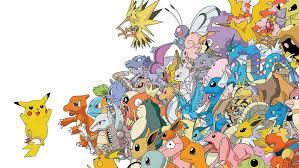

**Welcome to your first graded assignment! Hope that you are excited to implement and test everything you have learnt up until now. The dataset which you'll use includes information about Pokemons.**

**We have got an interesting set of questions for you to get a basic understanding of pandas and data visualization libraries. GOOD LUCK!**


***Let's get started with importing numpy, pandas, seaborn and matplotlib!***

Note - matplotlib should be imported with the command :

 `import matplotlib.pyplot as plt`

### 1) Start by importing all important libraries
For eg, "import numpy as np"

In [105]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### 2) Read the csv file and assign it to a variable .

In [106]:
f=pd.read_csv("https://drive.google.com/uc?export=download&id=1n_WVE7ax4gomqDyLvDFUYh8kTGQG38uz")

### 3) Display shape of dataframe
Expected Output - (800, 13)

In [107]:
print(f.shape)

(800, 13)


### 4) Print all columns of dataframe
Return an array containing names of all the columns.

In [108]:
print(f.columns.values)

['#' 'Name' 'Type 1' 'Type 2' 'Total' 'HP' 'Attack' 'Defense' 'Sp. Atk'
 'Sp. Def' 'Speed' 'Generation' 'Legendary']


### 5) Remove the column '#' and update the dataframe.

In [109]:
del f["#"]

### 6) Set the 'Name' column as the index of dataframe

In [110]:
f=f.set_index("Name")

###  7) Print a list of all the unique Type-1 powers

In [111]:
print(f["Type 1"].unique)

<bound method Series.unique of Name
Bulbasaur                  Grass
Ivysaur                    Grass
Venusaur                   Grass
VenusaurMega Venusaur      Grass
Charmander                  Fire
                          ...   
Diancie                     Rock
DiancieMega Diancie         Rock
HoopaHoopa Confined      Psychic
HoopaHoopa Unbound       Psychic
Volcanion                   Fire
Name: Type 1, Length: 800, dtype: object>


### 8) Create a column which contains the Type 1 and Type 2 abilities of pokemons, seperated with a '+'' sign. Also, display the no. of pokemons that have type-1 power as 'Psychic' and type 2 power as 'Flying' using this new column.

In [112]:
f["Combined"]=f["Type 1"]+"+"+f["Type 2"]

c=f[f["Combined"]=="Psychic+Flying"].shape
print(c)

(6, 12)


## GRADED Questions (To be answered in the quiz)
### Try to retrieve some information from the data and answer the questions below . BEST OF LUCK !!

### 1. How many pokemons have 'Mega' in their name?

In [113]:
lis=f.index.str.contains("Mega")
print(lis.sum())

49


### 2. What is the standard deviation of Sp. Def. in the dataset ?

In [114]:
fun=f["Sp. Def"].std()
print(fun)

27.82891579711745


### 3. What percentage (upto 3 decimal places) of pokemons are legendary ?

In [115]:
all_l=f["Legendary"].sum()
r=len(f)
print((all_l/r)*100)

8.125


### 4. Name the pokemon(s) with Maximum Defense.

In [116]:
m=f["Defense"].max()
fun=f[f["Defense"]==m]
print(fun)

                    Type 1  Type 2  Total  HP  Attack  Defense  Sp. Atk  \
Name                                                                      
SteelixMega Steelix  Steel  Ground    610  75     125      230       55   
Shuckle                Bug    Rock    505  20      10      230       10   
AggronMega Aggron    Steel     NaN    630  70     140      230       60   

                     Sp. Def  Speed  Generation  Legendary      Combined  
Name                                                                      
SteelixMega Steelix       95     30           2      False  Steel+Ground  
Shuckle                  230      5           2      False      Bug+Rock  
AggronMega Aggron         80     50           3      False           NaN  


### 5. Which poison pokemon has the strongest attack ?

In [117]:
a=(f['Type 1'] == 'Poison') | (f['Type 2'] == 'Poison')
fun=f[a] # Corrected: Removed unnecessary list brackets
m=fun["Attack"].max()
print(fun[fun["Attack"]==m])

                      Type 1  Type 2  Total  HP  Attack  Defense  Sp. Atk  \
Name                                                                        
BeedrillMega Beedrill    Bug  Poison    495  65     150       40       15   

                       Sp. Def  Speed  Generation  Legendary    Combined  
Name                                                                      
BeedrillMega Beedrill       80    145           1      False  Bug+Poison  


### 6. Using seaborn make different types of plots, observe the trend and answer the questions given in the form.

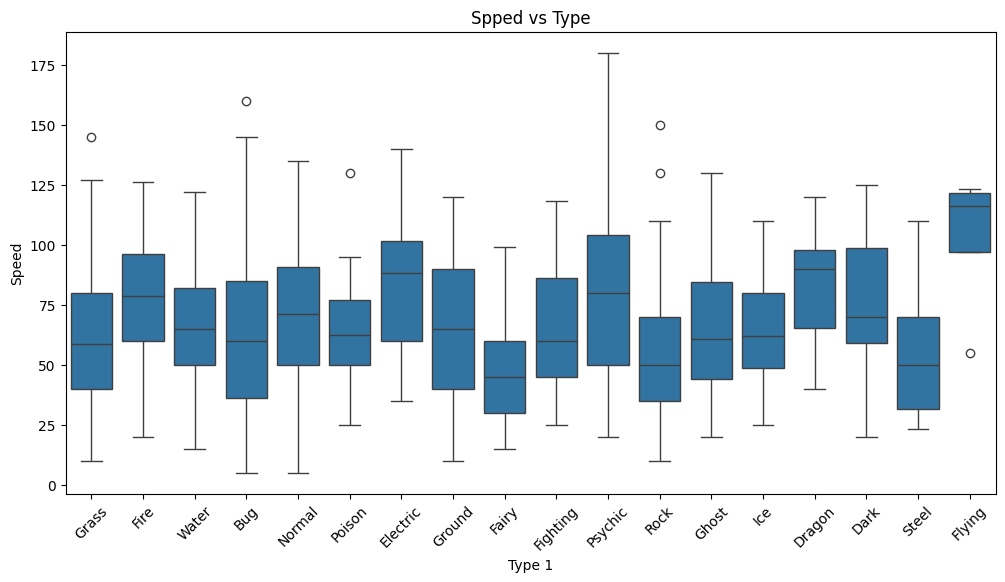

In [118]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
sns.boxplot(data=f, x='Type 1', y='Speed')
plt.xticks(rotation=45)
plt.title('Spped vs Type')
plt.show()

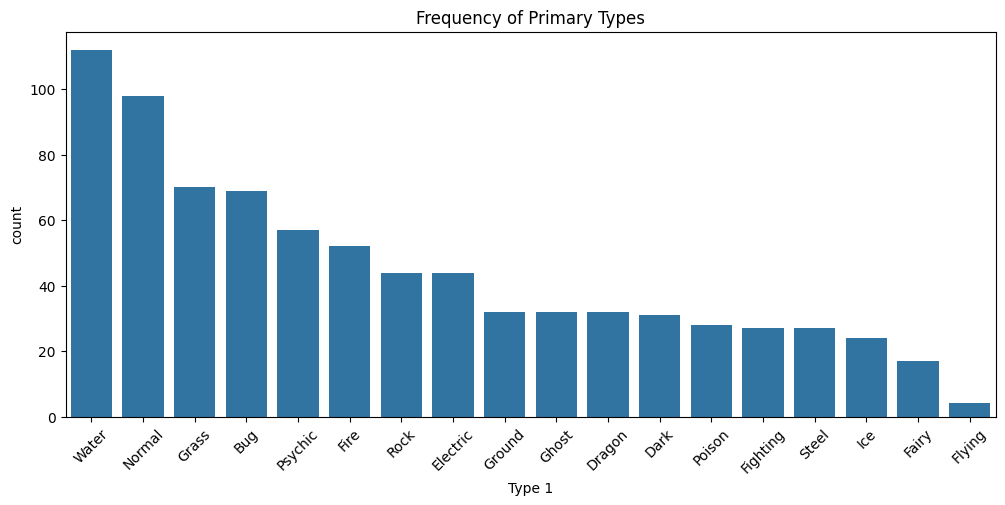

In [119]:
plt.figure(figsize=(12, 5))
sns.countplot(data=f, x='Type 1', order=f['Type 1'].value_counts().index)
plt.xticks(rotation=45)
plt.title('Frequency of Primary Types')
plt.show()

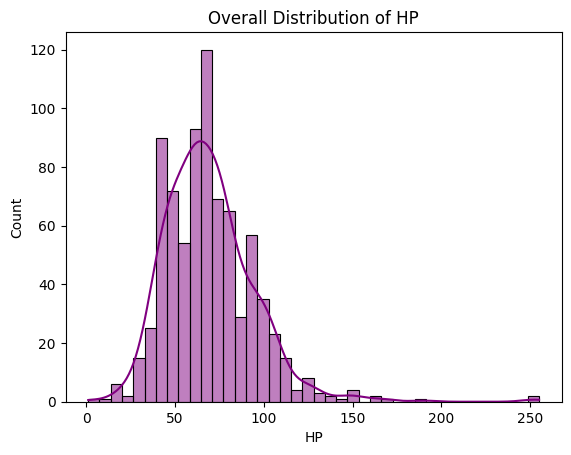

In [120]:
sns.histplot(data=f, x='HP', kde=True, color='purple')
plt.title('Overall Distribution of HP')
plt.show()

### 7. Which is the second fastest non-legendary 'Ghost' type pokemon from 4th generation ?

In [121]:
ghost=((f['Type 1']=='Ghost') | (f['Type 2']=='Ghost'))
gen=(f["Generation"]==4)
lene=(f["Legendary"]==False)

ans=f[ghost & gen & lene]
sort = ans.sort_values(by='Speed', ascending=False)
print(sort.index[1])

Mismagius


### 8. How many non-legendary pokemons have stronger defence but weaker attack than Charizard?

In [122]:
att = f.loc['Charizard', 'Attack']
defe = f.loc['Charizard', 'Defense']
fun=f[(f['Legendary']==False) & (f['Attack']<att) & (f['Defense']>defe)]
print(len(fun))

116



## ***Bonus Questions***
## Here are some bonus questions that you can try further !

### These questions are UNGRADED, and are given as an extra exercise.

### Which pokemon has the highest combined value of Attack and Sp. Atk ?

In [123]:
fen=f['Attack']+f['Sp. Atk']
sor=fen.sort_values(ascending=False)
print(sor.iloc[0])

360


### Which type of legendary pokemons are the most common?

In [124]:
fen=f[f['Legendary']==True]
most_common = fen['Type 1'].value_counts().idxmax()
print(most_common)

Psychic


### How many generation-3, non-legendary pokemons have higher HP than the weakest generation-6, legendary pokemon?

In [125]:
nonl=(f['Legendary']==False)
gen6=f[f['Generation']==6]
gen3=(f['Generation']==3)
sor=gen6.sort_values(by='HP', ascending=True)
low=sor.iloc[0]['HP']
fen=(f['HP']>low)
ans=f[fen & nonl & gen3]
print(len(ans))

131


### Print out the third slowest pokemon(s) in the dataset.

In [126]:
fen=f['Speed']
sor=fen.sort_values(ascending=True)
print(sor.iloc[2])

10


### Which pokemon type has the highest average HP?

In [127]:
fen=f['HP']
sor=fen.sort_values(ascending=False)
print(sor.iloc[0])

255
